#PROJETO - ANÁLISE DE DADOS

##Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

##1. Lendo Dataframe e Exploração

In [10]:
df = pd.read_csv('student-por.csv', sep=';') #comando para ler o database
df.head() #5 primeiras linhas


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
df.info() #informações gerais do dataframe

In [ ]:
df.describe() #Informações estatísticas descritivas

In [ ]:
df.shape #Número de linhas e colunas

##2. Limpeza do Dataframe

In [ ]:
df.isnull().sum() #número de valores nulos por colunas

In [ ]:
df.dtypes #Verifica o tipo de dados de cada coluna

# CONVERTER O VALOR DAS NOTAS PARA FLOAT
df['G1'] = df['G1'].astype(float)
df['G2'] = df['G2'].astype(float)
df['G3'] = df['G3'].astype(float)
df.dtypes

##3. Filtragem e Seleção de Dados

In [ ]:
df[['age', 'sex', 'G1']] #seleciona apenas as colunas 'age', 'sex', 'G1'

In [ ]:
df[df['age']>18] #filtra alunos maiores de 18

In [ ]:
df[df['absences']>5] #filtra alunos com mais de 5 faltas

In [ ]:
df[(df['sex'] == 'F') & (df['absences']>5)] #filtra alunos do sexo feminino com mais de 5 faltas

###Criando coluna da média, mediana e desvio padrão das notas de cada aluno

In [78]:
df['mean'] = df[['G1','G2', 'G3']].mean(axis=1).round(2)/2
df['median'] = df[['G1', 'G2', 'G3']].median(axis=1).round(2)
df['desvio'] = df[['G1','G2', 'G3']].std(axis=1).round(2)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Walc,health,absences,G1,G2,G3,mean,median,desvio,classificacao
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,3,4,0.0,11.0,11.0,3.665,11.0,6.35,Aprovado
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,3,2,9.0,11.0,11.0,5.165,11.0,1.15,Aprovado
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,3,6,12.0,13.0,12.0,6.165,12.0,0.58,Aprovado
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,5,0,14.0,14.0,14.0,7.000,14.0,0.00,Aprovado
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,5,0,11.0,13.0,13.0,6.165,13.0,1.15,Aprovado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,2,5,4,10.0,11.0,10.0,5.165,10.0,0.58,Aprovado
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,1,1,4,15.0,15.0,16.0,7.665,15.0,0.58,Aprovado
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,5,6,11.0,12.0,9.0,5.335,11.0,1.53,Aprovado
647,MS,M,17,U,LE3,T,3,1,services,services,...,4,2,6,10.0,10.0,10.0,5.000,10.0,0.00,Aprovado


###Filtrando alunos aprovados e reprovados em uma tabela 'classificacao'

In [81]:
def classifica_aluno(media):
  if media>=6:
    return 'Aprovado'
  else:
    return 'Reprovado'

df['classificacao'] = df['mean'].apply(classifica_aluno)


##Análise Final

###Alunos aprovados

In [82]:
df['classificacao'].value_counts()

,count
classificacao,
Reprovado,344
Aprovado,305


###Média de notas por Sexo

In [83]:
df.groupby('sex')[['G1','G2', 'G3']].mean().round(2)

,G1,G2,G3
sex,,,
F,11.64,11.82,12.25
M,11.06,11.21,11.41


##Gráficos

###Gráfico de barra Alunos Aprovados vs Reprovados

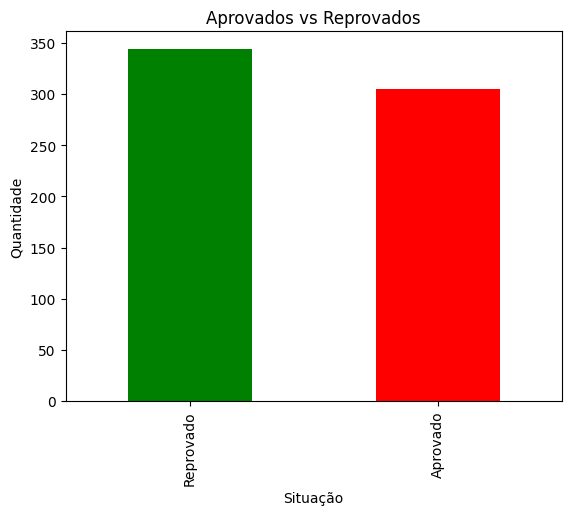

In [94]:
df['classificacao'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Aprovados vs Reprovados')
plt.xlabel('Situação')
plt.ylabel('Quantidade')
plt.show()

###Gráfico boxplot compararando as médias por gênero

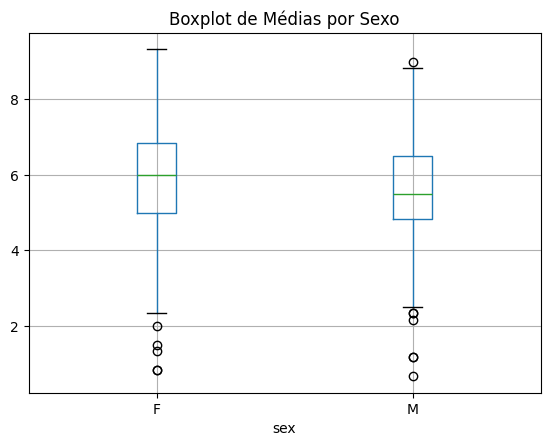

In [92]:
df.boxplot(column='mean', by='sex')
plt.title('Boxplot de Médias por Sexo')
plt.suptitle('')
plt.show()

###Gráfico Histograma das Médias gerais

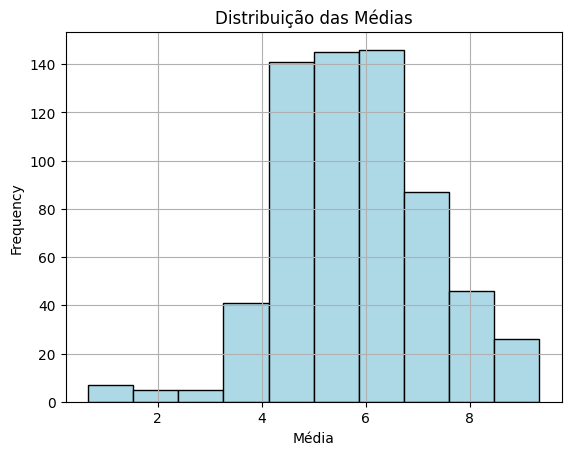

In [93]:
df['mean'].plot(kind='hist', bins=10, color='lightblue', edgecolor='black')
plt.title('Distribuição das Médias')
plt.xlabel('Média')
plt.grid(True)
plt.show()